# Lab 2 - By Richard hoehn 

## Hotplate Pthread Performance Analysis

This notebook analyzes the execution time of the multi-threaded Hotplate Problem implementation from Lab 2.

The program was tested using different numbers of POSIX threads on both **Apple/macOS** and **Linux** systems. Execution times were recorded to a CSV file and are compared in this notebook.

The analysis includes:

- Average execution time for each thread count
- Comparison between Apple and Linux systems
- Bar charts showing execution time versus number of threads
- Identification of the fastest thread count for each operating system
- Comparison of scaling behavior as additional threads are added

The Apple system used **16 CPU cores**, while the Linux system used **20 CPU cores**.

Lower execution time indicates better performance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load results file
filename = 'res_01.txt'
df = pd.read_csv(filename)
df

,os,num_threads,time
0,Apple,1,12.254204
1,Apple,2,6.715341
2,Apple,4,3.689108
3,Apple,8,2.594449
4,Apple,16,3.034336
5,Apple,32,3.647421
6,Linux,1,15.781997
7,Linux,2,8.658970
8,Linux,4,4.338191
9,Linux,8,2.161739


In [3]:
# Average repeated runs for each OS and thread count
avg_df = (
    df.groupby(["os", "num_threads"], as_index=False)["time"]
      .mean()
)

avg_df

,os,num_threads,time
0,Apple,1,12.270611
1,Apple,2,6.673890
2,Apple,4,3.726449
3,Apple,8,2.508138
4,Apple,16,2.973638
5,Apple,32,3.631064
6,Linux,1,15.785520
7,Linux,2,8.630362
8,Linux,4,4.335748
9,Linux,8,2.163365


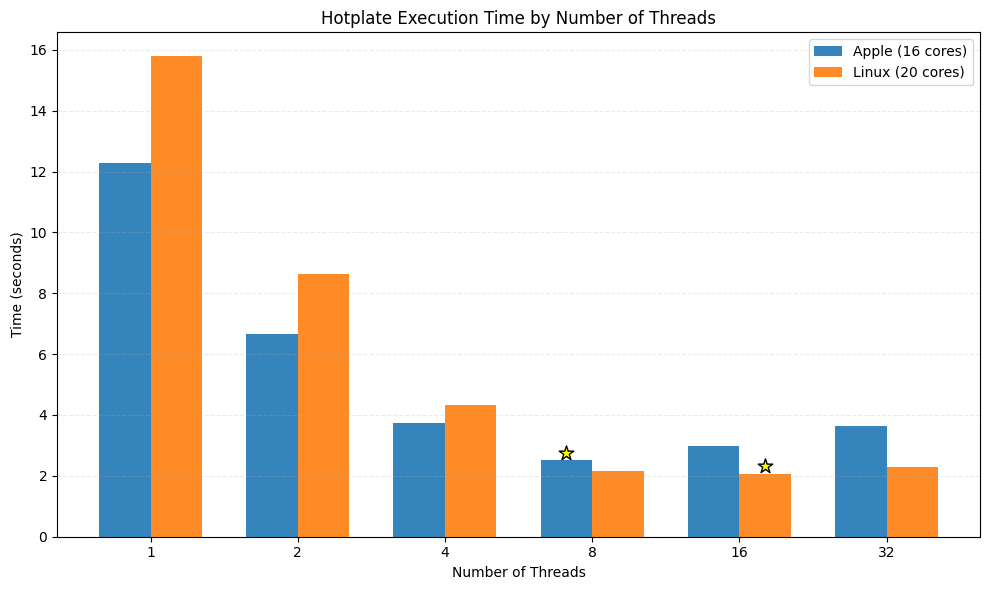

In [4]:
# Thread counts in desired order
thread_counts = sorted(avg_df["num_threads"].unique())

# Convert positions to evenly-spaced categorical positions
x = np.arange(len(thread_counts))

bar_width = 0.35

apple = avg_df[avg_df["os"] == "Apple"].set_index("num_threads")
linux = avg_df[avg_df["os"] == "Linux"].set_index("num_threads")

apple_times = [
    apple.loc[t, "time"] if t in apple.index else np.nan
    for t in thread_counts
]

linux_times = [
    linux.loc[t, "time"] if t in linux.index else np.nan
    for t in thread_counts
]



plt.figure(figsize=(10, 6))

plt.bar(
    x - bar_width / 2,
    apple_times,
    width=bar_width,
    label="Apple (16 cores)",
    alpha=0.9
)

plt.bar(
    x + bar_width / 2,
    linux_times,
    width=bar_width,
    label="Linux (20 cores)",
    alpha=0.9
)

plt.xticks(x, thread_counts)

plt.xlabel("Number of Threads")
plt.ylabel("Time (seconds)")
plt.title("Hotplate Execution Time by Number of Threads")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Find the lowest time for each OS
apple_min_index = np.nanargmin(apple_times)
linux_min_index = np.nanargmin(linux_times)

# Add yellow stars above the fastest bars
plt.scatter(
    x[apple_min_index] - bar_width / 2,
    apple_times[apple_min_index] + 0.25,
    marker="*",
    s=120,
    color="yellow",
    edgecolor="black",
    zorder=5
)

plt.scatter(
    x[linux_min_index] + bar_width / 2,
    linux_times[linux_min_index] + 0.25,
    marker="*",
    s=120,
    color="yellow",
    edgecolor="black",
    zorder=5
)

# plt.xticks(
#     [0, 1, 3, 7, 15, 23, 31, 39, 47, 63],
#     [1, 2, 4, 8, 16, 24, 32, 40, 48, 64]
# )

plt.legend()

plt.legend()
plt.tight_layout()

plt.savefig(f"Lab2_Perf_{filename}.png", dpi=300, bbox_inches="tight")

plt.show()